# Machine Project 6: EDGAR Web Logs

#### <span style="color:red">Make sure to read the [README](README.md) before starting this project</span>

## Required Information

Please fill out the following details.  
- Enter your **full name (as it appears on Canvas)** and **NetID**.  
- If you are working in a group (maximum of 3 members), include the **full names and NetIDs** of all your partners.  
- If you're working alone, enter `None` for the partner fields.

> **Important:** Each student must submit the project individually.  
Failure to complete this section may result in your submission being flagged for plagiarism.

In [1]:
# Project: MP6
# Student 1: zhengyang yu, zyu447
# Student 2: Holly Li, wli682
# Student 3: renxiang chao, rchao5

## <span style="color:red">Important:</span>

* **Before you begin**, make sure to `pull` any changes from GitLab. From the terminal, run:
```
git checkout main
git pull
git checkout MP6
git merge main
```
* Follow all instructions carefully. If anything is unclear, attend office hours or post on Piazza.
* You may add additional code cells as needed. However, **only cells with `#Q_` in the code will be graded**.
* **Do not use `print()` to display answers**; instead, ensure that each answer is the **last expression in a cell** so that it is automatically outputted by the notebook.
* To test, **Restart and Run all Cells** then **save the notebook** and run `python3 tester.py` from the terminal

> ⚠️ **Reminders:**
>
> - Make sure you are on the `MP6` branch by running `git branch` and checking the output.
> - Frequently `add`, `commit`, and `push` your code to avoid losing progress.


In [2]:
# Add additional imports used throughout the project here

import pickle # used for grading graphs

import re
from zipfile import ZipFile
import geopandas as gpd
import graphviz
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import box
import edgar_utils

# these lines automatically reload modules when their code changes
%load_ext autoreload
%autoreload 2

# Group Part (75%)

For this portion of the machine project, you may collaborate with your group members in any way (including looking at group members' code). You may also seek help from CS 320 course staff (peer mentors, TAs, and the instructor). You **may not** seek or receive help from other CS 320 students (outside of your group) or anybody else outside of the course.

## Part 1: `server_log.zip` analysis
> 📄 **Work in:** [`mp6.ipynb`](mp6.ipynb)

In [3]:
# Use pandas to read in "server_log.zip as a csv file"
with ZipFile("server_log.zip") as z:
    with z.open("rows.csv") as f:
        df = pd.read_csv(f)

### Q1: What's the total size in bytes of the files requested?

Look at the `size` column of the CSV in `server_log.zip`.  We want to include duplicates here; this gives us an estimate of the amount of network traffic handled by EDGAR (since this data is only a sample, the true value will be even larger). Answer with an integer. 

**Note:** If you use `numpy` make sure to cast the final answer to an `int`.

In [4]:
#Q1
int(df["size"].sum())

24801002666

### Q2: How many filings have been accessed by the 10 IPs with the most accesses?

Answer with a dictionary, with the (anonymized) IP as key and the number of requests seen in the logs as the values. Each row in the logs corresponds to one request. Note that the anonymized IP addresses are consistent between requests.

**Hint:** for this question and most of the others expecting dictionary output, it might be easiest to use Pandas operations to process the data into a `Series` and to use the `to_dict()` method. Consider using tools like `groupby`, `apply`, and aggregation methods like `size()`. In Q30-32 from [MP1](../mp1/README.md), there is an example of `apply`.


In [5]:
#Q2
df["ip"].value_counts().head(10).to_dict()

{'54.152.17.ccg': 12562,
 '183.195.251.hah': 6524,
 '52.45.218.ihf': 5562,
 '68.180.231.abf': 5493,
 '204.212.175.bch': 4708,
 '103.238.106.gif': 4428,
 '208.77.215.jeh': 3903,
 '208.77.214.jeh': 3806,
 '217.174.255.dgd': 3551,
 '82.13.163.caf': 3527}

### Q3: What fraction of the requests had errors?

Any request with a status code greater than or equal to 400 has an error. Answer with a floating point number. 

**Note:** If you use `numpy` make sure to cast the final answer to a `float`.

In [6]:
#Q3
float((df["code"] >= 400).mean())

0.03466852724527611

### Q4: What is the second most frequently accessed file?

Answer with a string formatted like so: "cik/accession/extention" (these are the names of columns in "rows.csv").

In [7]:
#Q4
files = (
    df["cik"].astype(int).astype(str) + "/" +
    df["accession"].astype(str) + "/" +
    df["extention"].astype(str)
)

files.value_counts().index[1]

'1584509/0001584509-16-000514/armk-20160930_def.xml'

## Part 2: Creating `edgar_utils.py` module
> 📄 **Work in:** [`edgar_utils.py`](edgar_utils.py)

This part is to be started during [Lab 9](../../labs/Lab9/README.md). Finish the `edgar_utils.py` module now if you didn't have enough time
during the scheduled lab.

## Part 3: Using `edgar_utils.py` module
> 📄 **Work in:** [`mp6.ipynb`](mp6.ipynb)

### Q5: Which region accesses resources most heavily in `server_log.zip`?

Use your `lookup_region` function and answer with a string.

In [8]:
#Q5
df["ip"].apply(edgar_utils.lookup_region).value_counts().idxmax()

'United States of America'

### Q6: What fraction of IPs in each region are high-volume users?

Consider IPs which accessed more than 300 EDGAR resoures to be
high-volume. This might indicate machines running automated scraping
and analysis tasks.

Note that given the sampling done in the data, the true EDGAR usage of
these machines is likely to be even heavier.

Answer with a dictionary, where the keys are the regions and the
values are the fraction (in floating point form) of IPs from that
region classified as high-volume.

**Example:**

Say "United States of America" has four IPs:
* 1.1.1.1 appears 1200 times in the logs
* 2.2.2.2 appears 900 times in the logs
* 3.3.3.3 appears 5 times in the logs
* 4.4.4.4 appears 234 times in the logs

This means that 1/2 of the IPs in the US are high volume, so there should be an entry like this:

```
{
    "United States of America": 0.5,
    ...
}
```

**Note:** Some of the filings are listed as having a region of '-'. Please include this in your final
answer.

**Note:** If you use `numpy` make sure to cast dictionary entries to `float`.

In [9]:
#Q6
ip_counts = df["ip"].value_counts()

ip_df = ip_counts.rename_axis("ip").reset_index(name="count")
ip_df["region"] = ip_df["ip"].apply(edgar_utils.lookup_region)
ip_df["high_volume"] = ip_df["count"] > 300

(
    ip_df.groupby("region")["high_volume"]
    .mean()
    .astype(float)
    .to_dict()
)

{'-': 0.0,
 'Algeria': 0.0,
 'Angola': 0.0,
 'Armenia': 0.0,
 'Australia': 0.07692307692307693,
 'Austria': 0.0,
 'Bangladesh': 0.0,
 'Brazil': 0.0,
 'Bulgaria': 0.3333333333333333,
 'Canada': 0.05357142857142857,
 'China': 0.016018306636155607,
 'Croatia': 0.0,
 'Cyprus': 0.0,
 'Czechia': 0.3333333333333333,
 'Denmark': 0.0,
 'Egypt': 0.0,
 'Estonia': 0.0,
 'Finland': 0.0,
 'France': 0.0036900369003690036,
 'Germany': 0.047619047619047616,
 'Greece': 0.0,
 'Honduras': 0.0,
 'Hong Kong': 0.037037037037037035,
 'Hungary': 0.0,
 'India': 0.08823529411764706,
 'Indonesia': 0.0,
 'Iraq': 0.0,
 'Ireland': 0.625,
 'Israel': 0.0,
 'Italy': 0.0,
 'Japan': 0.0,
 'Jersey': 0.0,
 'Jordan': 0.0,
 'Korea (Republic of)': 0.2,
 'Latvia': 0.0,
 'Lebanon': 0.0,
 'Liberia': 0.0,
 'Luxembourg': 0.0,
 'Malaysia': 0.0,
 'Mexico': 0.0,
 'Mongolia': 0.0,
 'Morocco': 0.0,
 'Netherlands': 0.0,
 'Nigeria': 0.0,
 'North Macedonia': 0.0,
 'Pakistan': 0.0,
 'Philippines': 0.0,
 'Poland': 0.0,
 'Portugal': 0.0,
 'R

### Requirement: `filings` dictionary

Read every file ending with .htm or .html in `docs.zip`, and create a `Filing`
object based on that file. Then, save that `Filing` object to a dictionary as follows:
- **Key:** The filepath for this filing object (ex. `850693/0000850693-07-000159/-index.htm`)
- **Value:** The `Filing` object created from this filepath.

Creating this dictionary once now will save us from needing to loop over all values
in future questions.

In [10]:
# Create `filings` dictionary
filings = {}

with ZipFile("docs.zip") as z:
    for name in z.namelist():
        if name.endswith(".htm") or name.endswith(".html"):
            with z.open(name) as f:
                html = f.read().decode("utf-8")
            filings[name] = edgar_utils.Filing(html)

### Q7: What dates appear in the `886982/0000769993-16-001958/-index.htm` file of `docs.zip`?

Read the HTML from this file and use it to create a `Filing` object,
from which you can access the `.dates` attribute.

In [11]:
#Q7
filings["886982/0000769993-16-001958/-index.htm"].dates

['2016-12-30', '2016-12-30', '2016-12-20']

### Q8: What is the distribution of states for the filings in `docs.zip`?

Answer with a dict, like the following:

```
{'CA': 92,
 'NY': 83,
 'TX': 67,
 'None': 56,
 'MA': 30,
 'IL': 25,
 'PA': 25,
 'CO': 25,
 ...
}
```

The showing order of each key-value pair doesn't really matter. Please include `None` in the
dictionary.

**Hint:** We created the `filings` dictionary above, which means we don't have to
iterate through `docs.zip` here again!

In [12]:
#Q8
pd.Series([f.state() for f in filings.values()]).value_counts(dropna=False).to_dict()

{'CA': 92,
 'NY': 83,
 'TX': 67,
 None: 56,
 'MA': 30,
 'CO': 25,
 'PA': 25,
 'IL': 25,
 'NJ': 23,
 'FL': 21,
 'VA': 15,
 'MN': 15,
 'CT': 14,
 'MD': 13,
 'MI': 11,
 'OH': 10,
 'GA': 9,
 'NC': 9,
 'WI': 9,
 'DE': 9,
 'OK': 7,
 'NV': 6,
 'IA': 6,
 'IN': 5,
 'AZ': 5,
 'KS': 5,
 'UT': 5,
 'MO': 4,
 'TN': 4,
 'WA': 3,
 'OR': 2,
 'LA': 2,
 'WV': 2,
 'NE': 2,
 'KY': 2,
 'MS': 1,
 'AL': 1,
 'SD': 1,
 'NM': 1,
 'VT': 1,
 'AR': 1,
 'ID': 1,
 'DC': 1,
 'ME': 1}

### Q9: What is the distribution for the ten most common addresses for the filings in `docs.zip`?

Answer in the same format as the previous question. Make sure to sort with `reverse=True`

Expected output:
```
{'2000 AVENUE OF THE STARS, 12TH FLOOR\nLOS ANGELES CA 90067': 134,
 '2000 AVENUE OF THE STARS, 12TH FLOOR\nLOS ANGELES CA 90067\n3102014100': 113,
 '3 LANDMARK SQUARE\nSUITE 500\nSTAMFORD CT 06901\n2033564400': 60,
 'C/O KKR ASSET MANAGEMENT LLC\n555 CALIFORNIA STREET, 50TH FLOOR\nSAN FRANCISCO CA 94104': 36,
 'C/O ARES MANAGEMENT LLC\n2000 AVENUE OF THE STARS, 12TH FLOOR\nLOS ANGELES CA 90067': 35,
 '4740 AGAR DRIVE\nRICHMOND A1 V7B 1A3': 25,
 'CENTRALIS S.A., 8-10 AVENUE DE LA GARE\nLUXEMBOURG N4 L-1610': 25,
 'CENTRALIS S.A., 8-10 AVENUE DE LA GARE\nLUXEMBOURG N4 L-1610\n352-26-186-1': 25,
 '3 LANDMARK SQUARE\nSUITE 500\nSTAMFORD CT 06901': 24,
 '801 CHERRY STREET\nSUITE 2100\nFORT WORTH TX 76102': 22}
```

In [13]:
#Q9
from collections import Counter

address_counts = Counter()

for filing in filings.values():
    address_counts.update(filing.addresses)

dict(sorted(address_counts.items(), key=lambda x: x[1], reverse=True)[:10])

{'2000 AVENUE OF THE STARS, 12TH FLOOR\nLOS ANGELES CA 90067': 134,
 '2000 AVENUE OF THE STARS, 12TH FLOOR\nLOS ANGELES CA 90067\n3102014100': 113,
 '3 LANDMARK SQUARE\nSUITE 500\nSTAMFORD CT 06901\n2033564400': 60,
 'C/O KKR ASSET MANAGEMENT LLC\n555 CALIFORNIA STREET, 50TH FLOOR\nSAN FRANCISCO CA 94104': 36,
 'C/O ARES MANAGEMENT LLC\n2000 AVENUE OF THE STARS, 12TH FLOOR\nLOS ANGELES CA 90067': 35,
 '4740 AGAR DRIVE\nRICHMOND A1 V7B 1A3': 25,
 'CENTRALIS S.A., 8-10 AVENUE DE LA GARE\nLUXEMBOURG N4 L-1610': 25,
 'CENTRALIS S.A., 8-10 AVENUE DE LA GARE\nLUXEMBOURG N4 L-1610\n352-26-186-1': 25,
 '3 LANDMARK SQUARE\nSUITE 500\nSTAMFORD CT 06901': 24,
 '801 CHERRY STREET\nSUITE 2100\nFORT WORTH TX 76102': 22}

# Individual Part (25%)

For this portion of the machine project, you are only allowed to seek help from CS 320 course staff (peer mentors, TAs, and the instructor). You **may not** receive help from anyone else.

## Part 4: Combining logs with documents
> 📄 **Work in:** [`mp6.ipynb`](mp6.ipynb)

### Q10: What is the distribution of requests across industries?

For each request in the logs that has a corresponding filing in
`docs.zip`, lookup the SIC (ignore rows in the logs which refer to
pages not in `docs.zip`).

Answer with a dictionary, where the keys are the SIC and the values
are the number of times the resources of that industry were accessed.

If you're curious, consider looking up the industry names for the top
couple categories:
https://www.sec.gov/corpfin/division-of-corporation-finance-standard-industrial-classification-sic-code-list

Expected output:

```
{2834: 984,
 1389: 656,
 1311: 550,
 2836: 429,
 6022: 379,
 1000: 273,
 ...
 }
 ```

In [14]:
#Q10
from zipfile import ZipFile
import csv
from collections import defaultdict
import edgar_utils

sic_count = defaultdict(int)

with ZipFile("server_log.zip") as log_zip, ZipFile("docs.zip") as doc_zip:
    with log_zip.open("rows.csv") as f:
        reader = csv.DictReader(line.decode("utf-8") for line in f)
        doc_files = set(doc_zip.namelist())
        
        for row in reader:
            cik = str(int(float(row["cik"])))
            accession = row["accession"]
            ext = row["extention"]
            path = f"{cik}/{accession}/{ext}"
            
            if path not in doc_files:
                continue
            
            html = doc_zip.read(path).decode("utf-8", errors="ignore")
            
            filing = edgar_utils.Filing(html)
            sic = filing.sic
            
            if sic is not None:
                sic_count[sic] += 1

dict(sic_count)

{4931: 70,
 1000: 273,
 6021: 204,
 7371: 229,
 2860: 226,
 6211: 237,
 2834: 984,
 1389: 656,
 4522: 22,
 6282: 171,
 6022: 379,
 1700: 31,
 6331: 91,
 4813: 4,
 2836: 429,
 3620: 50,
 1311: 550,
 4841: 108,
 3272: 81,
 7200: 94,
 6513: 38,
 7374: 94,
 3510: 66,
 4512: 42,
 3826: 56,
 3678: 4,
 4911: 8,
 2510: 171,
 6798: 90,
 7830: 62,
 3571: 6,
 6221: 85,
 3621: 38,
 3695: 55,
 3590: 24,
 6321: 21,
 4812: 4,
 3312: 31,
 3842: 87,
 2870: 2,
 4955: 23,
 7370: 39,
 1040: 2,
 900: 39,
 4833: 7,
 6029: 83,
 3990: 34,
 5311: 90,
 5944: 33,
 3663: 23,
 8742: 27,
 5621: 99,
 8090: 32,
 4412: 43,
 8731: 25,
 7373: 48,
 8711: 2,
 6411: 3,
 3669: 2,
 5172: 36,
 3825: 164,
 3559: 20,
 2080: 1,
 3541: 1,
 7389: 26,
 2711: 1,
 7812: 25,
 7350: 1,
 1400: 3,
 5900: 35,
 3829: 73,
 5812: 19,
 3845: 2,
 6770: 2,
 3841: 14,
 7990: 1,
 2911: 1,
 6799: 46,
 1382: 2,
 3679: 5,
 3721: 1,
 5122: 34,
 5990: 1,
 1531: 4,
 5731: 1,
 5531: 1,
 6324: 30,
 2750: 1,
 4213: 35,
 1381: 31,
 2030: 1,
 3714: 1,
 7372


### Q11: How many requests were made in each hour?

Use `pd.to_datetime` (the `hour` attributes of the converted
timestamps may be useful) or string manipulation to process the `time`
column. Answer with a dictionary, where the keys are integers from 0
to 23 representing the hour of the day, and the values are the number
of requests made in that hour.

In [15]:
#Q11
from zipfile import ZipFile
import csv
from collections import defaultdict
import pandas as pd
import pickle

hour_count = defaultdict(int)

with ZipFile("server_log.zip") as log_zip:
    with log_zip.open("rows.csv") as f:
        reader = csv.DictReader(line.decode("utf-8") for line in f)
        
        for row in reader:
            dt = pd.to_datetime(f"{row['date']} {row['time']}")
            hour = dt.hour
            hour_count[hour] += 1

hour_count = dict(hour_count)

with open("Q11.pkl", "wb") as f:
    pickle.dump(hour_count, f)

hour_count

{0: 8305,
 1: 8242,
 2: 8550,
 3: 8850,
 4: 8343,
 5: 9783,
 6: 7761,
 7: 8213,
 8: 8292,
 9: 11033,
 10: 6377,
 11: 6435,
 12: 6155,
 13: 6006,
 14: 6654,
 15: 6512,
 16: 5680,
 17: 6487,
 18: 6356,
 19: 6211,
 20: 6066,
 21: 6164,
 22: 6098,
 23: 6283}

### Q12: What is the geographic overlap in interest between Australia, France, Indonesia, and Viet Nam?

Answer with a Digraph like the following:

<img src="img/digraph.png" width=400>

In addition to a node for each of these three countries, there should
be a node for each state having a filing accessed by somebody in one
of these countries.

An edge from a country to a state means somebody in that country
looked at least one filing for a company in that state.

**Important:** Make sure not to hardcode these values. It might be helpful to
define a list like `countries = ["Australia", "France", "Indonesia", "Viet Nam"]` and then loop over the filings for these countries only.

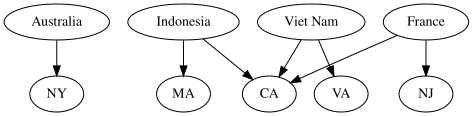

In [16]:
#Q12
import pickle
import pandas as pd
from zipfile import ZipFile
import graphviz
import edgar_utils

with ZipFile("server_log.zip") as z:
    with z.open("rows.csv") as f:
        logs = pd.read_csv(f)

docs = {}
with ZipFile("docs.zip") as z:
    for path in z.namelist():
        html = z.read(path).decode("utf-8", errors="ignore")
        filing = edgar_utils.Filing(html)
        docs[path] = {"state": filing.state()}

d = graphviz.Digraph()

countries = ["Australia", "France", "Indonesia", "Viet Nam"]
country_states = {c: set() for c in countries}

for _, row in logs.iterrows():
    cik = str(int(float(row["cik"])))
    accession = row["accession"]
    ext = row["extention"]
    path = f"{cik}/{accession}/{ext}"
    country = edgar_utils.lookup_region(row["ip"])

    if country in countries and path in docs:
        state = docs[path]["state"]
        if state is not None:
            country_states[country].add(state)

for c in countries:
    d.node(c)

all_states = set()
for states in country_states.values():
    all_states.update(states)

for s in all_states:
    d.node(s)

for c in countries:
    for s in country_states[c]:
        d.edge(c, s)

with open("Q12.pkl", "wb") as f:
    pickle.dump(d.source, f)

d

### Q13: Geographic Plotting of Postal Codes

You will plot geographic data from `locations.geojson` over a background map from `"shapes/cb_2018_us_state_20m.shp"`. Each point represents an address and should be colored by its **5-digit postal code**.

**Steps:**

1. **Extract ZIP codes from the address column**
   - Use a regex to find **5-digit ZIP codes**.
   - If the address has a state + ZIP, such as `CA 93821`, keep only the numeric code.
   - Drop invalid or missing ZIP codes.
2. **Filter ZIP codes**
   - Only keep rows where `10000 <= zipcode <= 60000`.
3. **Define and apply bounding box**
   - Use `box(west, south, east, north)` imported from `shapely.geometry.box`.
   - Crop both:
     - The background using `.intersection(bounds)`
     - The locations using `.intersects(bounds)`
4. **Project data**
   - After filtering, project **both datasets** to `epsg:2022`.
   - Do **not** project before cropping.
5. **Plot the data**
   - Plot the cropped background in `"lightgray"`.
   - Plot the points with:
     - `column="zipcode"`
     - `cmap="viridis"`
     - `legend=True` (adds a colorbar).
   - Hide axes with `ax.set_axis_off()`.


The result should look like this:

<img src="img/geo.png" width="400px">

**Hints:**

- **Regex:**
    - Use `re.findall(regex, address)` to extract ZIP codes.
    - Make sure that your regex matches two capital letters followed by some spaces and then a five-digit number. Then extract only the 5 digit code _(consider using parenthesis within your expression)_
    - Double-check the ZIP code range: it must be between 10000 and 60000 _(exclusive)_
- **Cropping and Projecting:**
    - Do not project before filtering or intersecting with the bounding box. Always crop in latitude/longitude (the original coordinate system) first.
    - When cropping the background map, make sure to use `background = background.intersection(bounds)`. Doing something like `background = background[background.intersects(bounds)]` will keep _entire_ state shapes that touch the box (e.g., showing all of Wisconsin), whereas `.intersection(bounds)` clips each state to just the portion inside the bounding box.
    - When filtering the locations, note that `.intersects(bounds)` returns a list/Series of True and False values. This boolean result should then be used to filter the original GeoDataFrame to keep only locations within the bounding box.
    - If your map looks distorted or blank, double-check that you projected **after** cropping and used the correct EPSG code.
- **Plotting:**
    - Use `legend=True` for the colorbar.
    - Most errors related to incorrect counts of regions, points, or metadata are caused by an incorrect regex used to filter data points. Make sure to carefully follow the directions above when defining your regex.


In [17]:
west = -90
east = -65
north = 50
south = 25

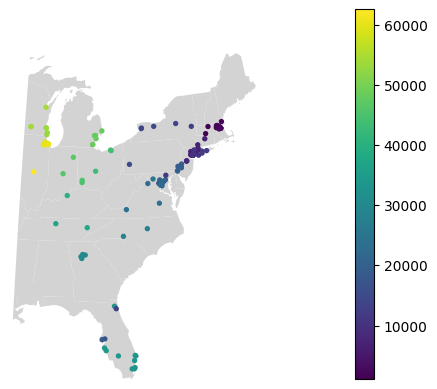

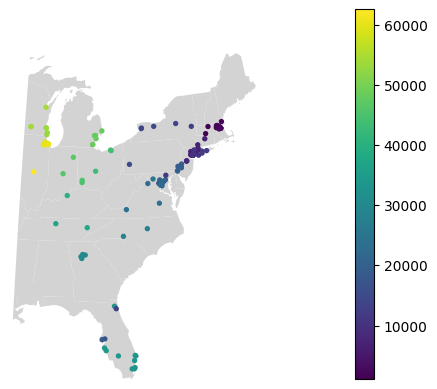

In [19]:
#Q13

bounds = box(west, south, east, north)

locations = gpd.read_file("locations.geojson")
background = gpd.read_file("shapes/cb_2018_us_state_20m.shp")

locations["zipcode"] = locations["address"].str.extract(r"(\d{5})(?:-\d{4})?")[0]
locations = locations.dropna(subset=["zipcode"]).copy()
locations["zipcode"] = locations["zipcode"].astype(int)

background = background.to_crs("EPSG:4326")
background = background.intersection(bounds)
background = gpd.GeoSeries(background, crs="EPSG:4326").to_crs(epsg=2022)

locations = locations[locations.intersects(bounds)].copy()
locations = locations.to_crs(epsg=2022)

proj_bounds = gpd.GeoSeries([bounds], crs="EPSG:4326").to_crs(epsg=2022).iloc[0]

fig, ax = plt.subplots()

background.plot(ax=ax, color="lightgray")
locations.plot(ax=ax, column="zipcode", legend=True, markersize=8)

ax.set_xlim(proj_bounds.bounds[0], proj_bounds.bounds[2])
ax.set_ylim(proj_bounds.bounds[1], proj_bounds.bounds[3])
ax.set_axis_off()

with open("Q13.pkl", "wb") as f:
    pickle.dump(fig, f)

fig

## <span style="color:red">Important:</span>
Make sure to follow these steps to submit the project
1. **Kernel > Restart Kernel and Run All Cells** and then save the notebook
2. Run `tester.py` to check your answers
3. Run the following commands from the terminal:
```
git status # make sure you are in the correct branch
git add mp6.ipynb edgar_utils.py Q12.pkl Q13.pkl
git commit -m "Finished MP6"
git push
```
4. Once you've pushed your project to GitLab, **verify that the pipeline ran successfully**.
    * Build > Jobs > Select the latest commit hash > Check tester output
5. Create a **_merge request_** to submit the project
    * Code > Merge requests > New merge request